In [37]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn

In [38]:
def get_lrs(optimizer, scheduler, steps=100, val_loss=None):
    lrs = []
    for t in range(steps):
        lrs += scheduler.get_last_lr()
        optimizer.step()
        if val_loss == None:
            scheduler.step()
        else:
            scheduler.step(val_loss[t])
    return lrs

### Caída escalonada

[(-0.1, 10.1),

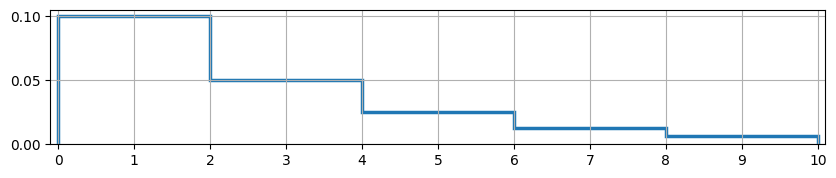

In [39]:
model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
steps = 10
lrs = get_lrs(optimizer, scheduler, steps=steps)
_, ax = plt.subplots(figsize=(10, 1.75))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1))

### Reduce on plateau

[(-0.1, 30.1),

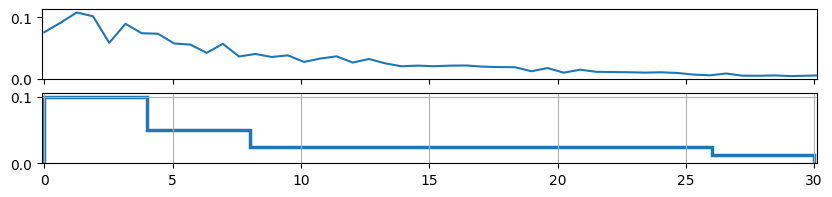

In [40]:
model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 30
x = np.linspace(0, steps + 1)
exp_lambda = 0.1
val_loss = torch.from_numpy(exp_lambda * np.exp(-exp_lambda * x))
val_loss += val_loss * (torch.rand_like(val_loss,) - 0.5) * 0.5
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
lrs = get_lrs(optimizer, scheduler, steps=steps, val_loss=val_loss)
_, (ax_loss, ax) = plt.subplots(2, figsize=(10, 2), sharex=True)
ax_loss.plot(x, val_loss)
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))

### CosineAnnealing

[(-0.1, 50.1),

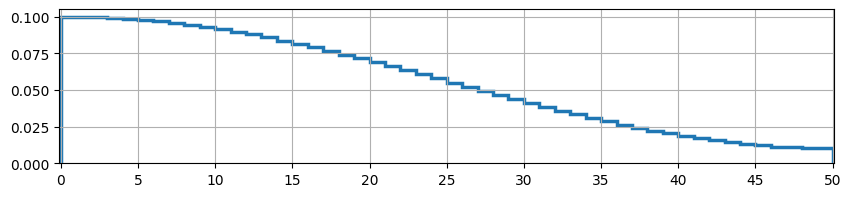

In [41]:
model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=0.010)
lrs = get_lrs(optimizer, scheduler, steps=steps)
_, ax = plt.subplots(figsize=(10, 2))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))

### Cosine Annealing with linear warmup         

[(-0.1, 50.1),

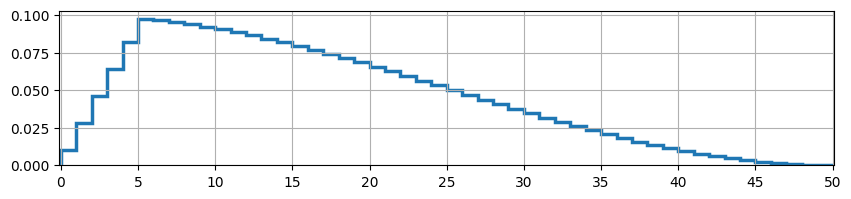

In [42]:
from timm.scheduler.cosine_lr import CosineLRScheduler

model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 50
scheduler = CosineLRScheduler(
    optimizer, t_initial=steps, warmup_t=5, warmup_lr_init=1e-2
)
lrs = [scheduler._get_lr(t)[0] for t in range(steps)]
_, ax = plt.subplots(figsize=(10, 2))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))

### Warmup Stable Decay (WSD)

[(-0.1, 50.1),

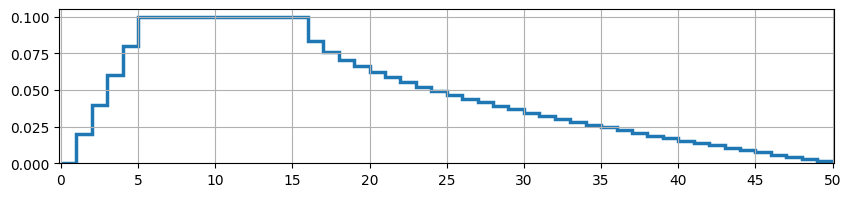

In [43]:
from pytorch_optimizer import get_wsd_schedule

model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 50
scheduler = get_wsd_schedule(optimizer, 5, 10, 35)
lrs = get_lrs(optimizer, scheduler, steps=steps)
_, ax = plt.subplots(figsize=(10, 2))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))

## Ejemplos

In [44]:
import torch


def exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=15):
    loss_fn = torch.nn.CrossEntropyLoss()
    for epoch in range(epochs):
        print(f"Epoch {epoch}: train:", end=" ")
        model.train()
        trsize, trbatches, trloss, tracc = 0, 0, 0, 0
        for batch in train_loader:
            X, y = batch["X"].to(device), batch["y"].to(device)
            trsize += len(X)
            trbatches += 1
            pred = model(X)
            loss = loss_fn(pred, y)
            trloss += loss.item()
            tracc += (pred.argmax(1) == y).type(torch.float).sum().item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
        trloss /= trbatches
        tracc /= trsize
        print(f"loss {trloss:g} acc {tracc:.2%} test:", end=" ")
        model.eval()
        tesize, tebatches, teloss, teacc = 0, 0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                X, y = batch["X"].to(device), batch["y"].to(device)
                tesize += len(X)
                tebatches += 1
                pred = model(X)
                teloss += loss_fn(pred, y).item()
                teacc += (pred.argmax(1) == y).type(torch.float).sum().item()
        teloss /= tebatches
        teacc /= tesize
        print(f"loss {teloss:g} acc {teacc:.2%}")

<br>
<br>

# CIFAR-10
### (Ejemplo)

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10).to(device)

In [47]:
import datasets
from torch.utils.data import DataLoader

ds = (
    datasets.load_dataset("uoft-cs/cifar10")
    .with_format("torch")
    .rename_columns({"img": "X", "label": "y"})
)


def datanorm(example):
    example["X"] = example["X"].to(torch.float) / 255.0
    return example


ds = ds.map(datanorm, batched=True)
train_ds = ds["train"].to_iterable_dataset(num_shards=1024)
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)
train_loader = DataLoader(train_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-5)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)

Epoch 0: train: loss 1.88128 acc 36.11% test: loss 1.82588 acc 48.85%
Epoch 1: train: loss 1.20041 acc 56.85% test: loss 2.13847 acc 54.95%
Epoch 2: train: loss 0.985328 acc 65.71% test: loss 0.907562 acc 68.62%
Epoch 3: train: loss 0.778086 acc 73.09% test: loss 0.861625 acc 70.39%
Epoch 4: train: loss 0.646873 acc 77.78% test: loss 0.783763 acc 74.02%


# MNIST

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10, in_chans=1).to(
    device
)

In [ ]:
import datasets
from torch.utils.data import DataLoader

ds = (
    datasets.load_dataset("ylecun/mnist")
    .with_format("torch")
    .rename_columns({"image": "X", "label": "y"})
)


def datanorm(example):
    example["X"] = example["X"].to(torch.float) / 255.0
    return example


ds = ds.map(datanorm, batched=True)
train_ds = ds["train"].to_iterable_dataset(num_shards=1024)
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)
train_loader = DataLoader(train_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-5)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)

# Fashion-MNIST

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10, in_chans=1).to(
    device
)

In [ ]:
import datasets
from torch.utils.data import DataLoader

ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("torch")
ds = ds.rename_columns({"image": "X", "label": "y"})


def datanorm(example):
    example["X"] = example["X"].to(torch.float) / 255.0
    return example


ds = ds.map(datanorm, batched=True)
train_ds = ds["train"].to_iterable_dataset(num_shards=1024)
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)
train_loader = DataLoader(train_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-5)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)